Umbralizacion Binaria y Binaria Inversa

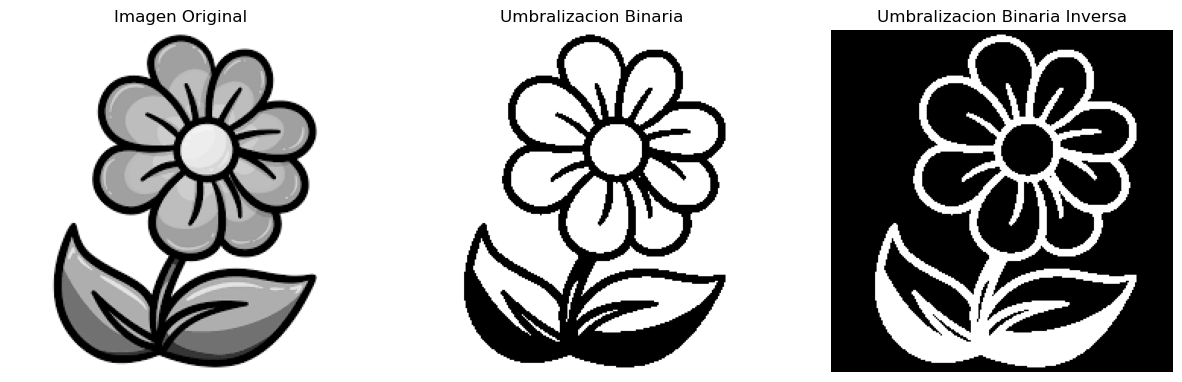

In [2]:
import cv2
import matplotlib.pyplot as plt
imagen = cv2.imread('flor.jpg',0) #lo lee en escala de grises (se puede usar color to gray)
#umbralizacion binaria
_,umbral_binario = cv2.threshold(imagen,127,255,cv2.THRESH_BINARY) #devulve dos valores metricas y la imagen umbralizada
#umbralizacion binaria inversa
_,umbral_binaria_inv = cv2.threshold(imagen,127,255,cv2.THRESH_BINARY_INV)

plt.figure(figsize=(15,5))
#imagen original
plt.subplot(1,3,1)
plt.imshow(imagen,cmap='gray')
plt.title('Imagen Original')
plt.axis('off')
#umbralizacion binaria
plt.subplot(1,3,2)
plt.imshow(umbral_binario,cmap='gray')
plt.title('Umbralizacion Binaria')
plt.axis('off')
#umbralizacion binaria inversa
plt.subplot(1,3,3)
plt.imshow(umbral_binaria_inv,cmap='gray')
plt.title('Umbralizacion Binaria Inversa')
plt.axis('off')
plt.show()

Filtro Bayer

es el patrón de colores que usan la mayoría de sensores: cada píxel captura solo R, G o B. Se aplica para "simular" cómo el sensor ve los colores (mosaico CFA) y luego reconstruir la imagen a color mediante demosaicing

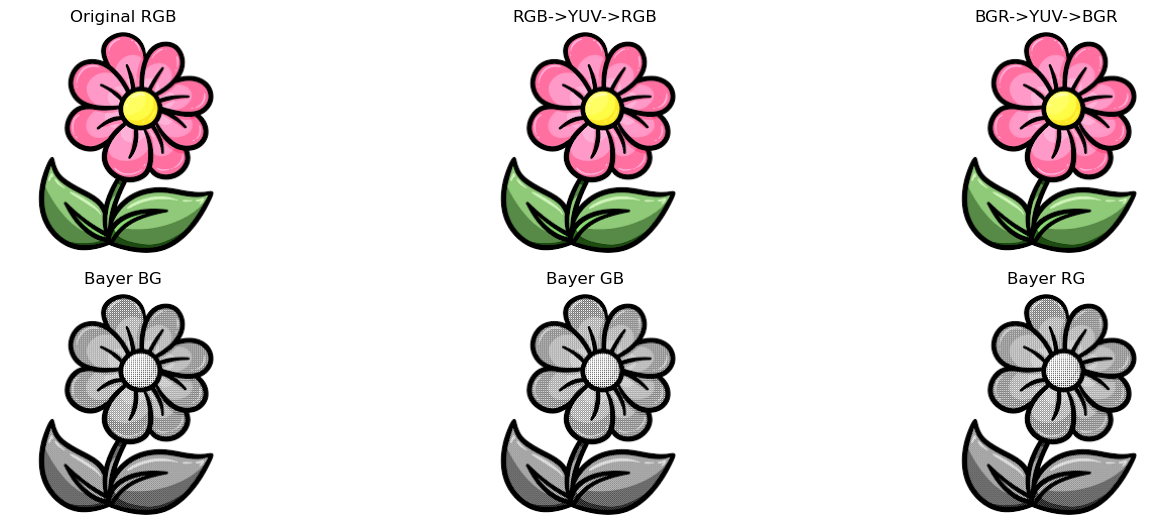

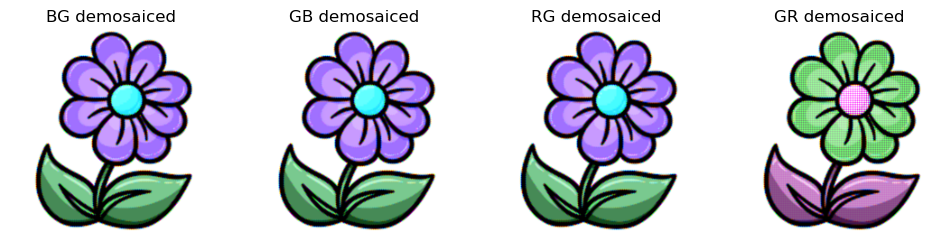

In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = 'flor.jpg'
bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)  # OpenCV lee en BGR

h, w = bgr.shape[:2]

def make_bayer(bgr_img, pattern):
    # pattern: 'BG','GB','RG','GR' 
    bayer = np.zeros((h, w), dtype=np.uint8)
    B = bgr_img[..., 0]; G = bgr_img[..., 1]; R = bgr_img[..., 2]
    if pattern == 'BG':
        bayer[0::2,0::2] = B[0::2,0::2]
        bayer[0::2,1::2] = G[0::2,1::2]
        bayer[1::2,0::2] = G[1::2,0::2]
        bayer[1::2,1::2] = R[1::2,1::2]
    elif pattern == 'GB':
        bayer[0::2,0::2] = G[0::2,0::2]
        bayer[0::2,1::2] = B[0::2,1::2]
        bayer[1::2,0::2] = R[1::2,0::2]
        bayer[1::2,1::2] = G[1::2,1::2]
    elif pattern == 'RG':
        bayer[0::2,0::2] = R[0::2,0::2]
        bayer[0::2,1::2] = G[0::2,1::2]
        bayer[1::2,0::2] = G[1::2,0::2]
        bayer[1::2,1::2] = B[1::2,1::2]
    elif pattern == 'GR':
        bayer[0::2,0::2] = G[0::2,0::2]
        bayer[0::2,1::2] = R[0::2,1::2]
        bayer[1::2,0::2] = B[1::2,0::2]
        bayer[1::2,1::2] = G[1::2,1::2]
    else:
        raise ValueError("pattern debe ser uno de: 'BG','GB','RG','GR'")
    return bayer

# detectar flags Bayer disponibles en cv2
candidates = [
    'COLOR_BayerBG2BGR','COLOR_BayerGB2BGR','COLOR_BayerRG2BGR','COLOR_BayerGR2BGR',
    'COLOR_BayerBG2RGB','COLOR_BayerGB2RGB','COLOR_BayerRG2RGB','COLOR_BayerGR2RGB',
    'COLOR_BayerBG2BGR_VNG','COLOR_BayerGB2BGR_VNG','COLOR_BayerRG2BGR_VNG','COLOR_BayerGR2BGR_VNG'
]
flags = [name for name in candidates if hasattr(cv2, name)]

# patrones a probar
patterns = {'BG':'BG','GB':'GB','RG':'RG','GR':'GR'}

results = {}
for pname, code in patterns.items():
    bayer = make_bayer(bgr, code)
    demosaics = {}
    for flag_name in flags:
        # elegir solo flags que contienen el patrón letters (BG,GB,RG,GR) or generic
        if pname in flag_name or all(p not in flag_name for p in patterns.keys()):
            flag = getattr(cv2, flag_name)
            try:
                out = cv2.cvtColor(bayer, flag)
                demosaics[flag_name] = out
            except Exception:
                pass
    results[pname] = (bayer, demosaics)

# conversiones RGB <-> YUV (usar RGB ordering para el usuario)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
rgb2yuv = cv2.cvtColor(rgb, cv2.COLOR_RGB2YUV)
yuv2rgb = cv2.cvtColor(rgb2yuv, cv2.COLOR_YUV2RGB)

# también BGR <-> YUV (OpenCV estándar)
bgr2yuv = cv2.cvtColor(bgr, cv2.COLOR_BGR2YUV)
yuv2bgr = cv2.cvtColor(bgr2yuv, cv2.COLOR_YUV2BGR)

# mostrar resultados
plt.figure(figsize=(14, 8))
plt.subplot(3, 3, 1); plt.imshow(rgb); plt.title('Original RGB'); plt.axis('off')
plt.subplot(3, 3, 2); plt.imshow(cv2.cvtColor(rgb2yuv, cv2.COLOR_YUV2RGB)); plt.title('RGB->YUV->RGB'); plt.axis('off')
plt.subplot(3, 3, 3); plt.imshow(cv2.cvtColor(bgr2yuv, cv2.COLOR_YUV2BGR)[:,:,::-1]); plt.title('BGR->YUV->BGR'); plt.axis('off')

# mostrar un patrón Bayer + uno o dos demosaics (los disponibles)
row = 2
col = 1
for pname, (bayer, demosaics) in results.items():
    plt.subplot(3, 3, 3 + col); plt.imshow(bayer, cmap='gray'); plt.title(f'Bayer {pname}'); plt.axis('off')
    col += 1
    if col > 3: break

plt.tight_layout()
plt.show()

# mostrar primero demosaiced por patrón  versión corregida
n = len(results)                # usar tantas columnas como patrones 
plt.figure(figsize=(3*n, 3))
for i, (pname, (bayer, demosaics)) in enumerate(results.items(), start=1):
    if demosaics:
        img = next(iter(demosaics.values()))
        plt.subplot(1, n, i)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f'{pname} demosaiced')
        plt.axis('off')
    else:
        plt.subplot(1, n, i)
        plt.imshow(bayer, cmap='gray')
        plt.title(f'{pname} (sin dem)')
        plt.axis('off')
plt.show()

# guardar demosaiced para inspección
out_dir = os.path.join(os.path.dirname(img_path), 'bayer_outputs')
os.makedirs(out_dir, exist_ok=True)
for pname, (bayer, demosaics) in results.items():
    for flag_name, img_out in demosaics.items():
        fname = f'{pname}_{flag_name}.png'
        cv2.imwrite(os.path.join(out_dir, fname), img_out)